In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(df.duplicated().sum())
df.isna().sum()

0


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df = df.drop_duplicates()

In [7]:
df['MultipleLines'].unique()

<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [8]:
BinCols = ['Partner','Dependents','PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']

def toBin(d):
    if str(d).lower() == 'yes':
        return 1
    else: return 0

for col in BinCols:
    df[col] = df[col].apply(toBin).astype(int)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

In [10]:
df.drop(columns=['customerID','gender'], inplace=True)

In [11]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,45,0,No phone service,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


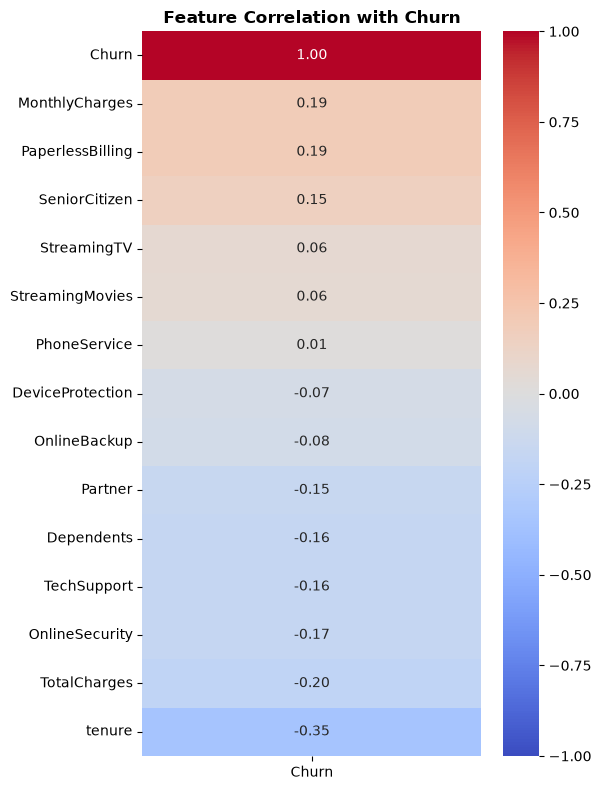

In [12]:
plt.figure(figsize=(6, 8))
churn_corr = df.corr(numeric_only=True)[['Churn']].sort_values(by='Churn', ascending=False)

sns.heatmap(churn_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation with Churn", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

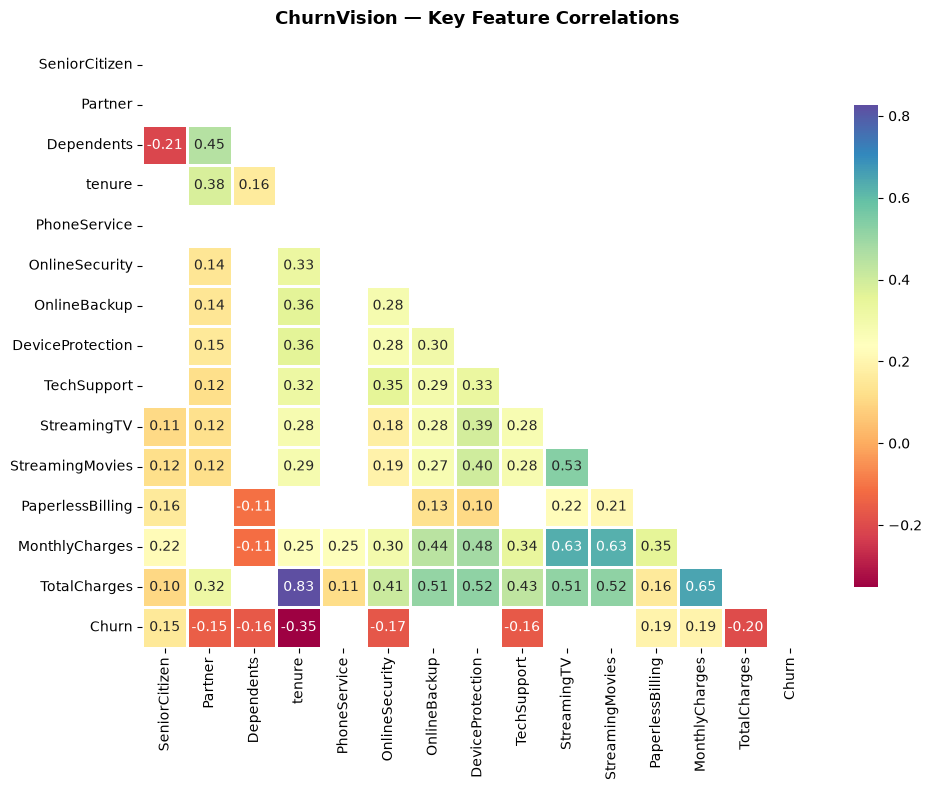

In [13]:
plt.figure(figsize=(10, 8))


corr_matrix = df.corr(numeric_only=True)

# Create a mask to hide the upper triangle (removes duplicate info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Optional: Also hide weak correlations (between -0.1 and 0.1) to reduce clutter
mask = mask | (abs(corr_matrix) < 0.1)

# Plot clean heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="Spectral",        # High contrast palette for quick reading
    linewidths=1, 
    linecolor='white',
    cbar_kws={"shrink": 0.8}
)

plt.title("ChurnVision — Key Feature Correlations", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

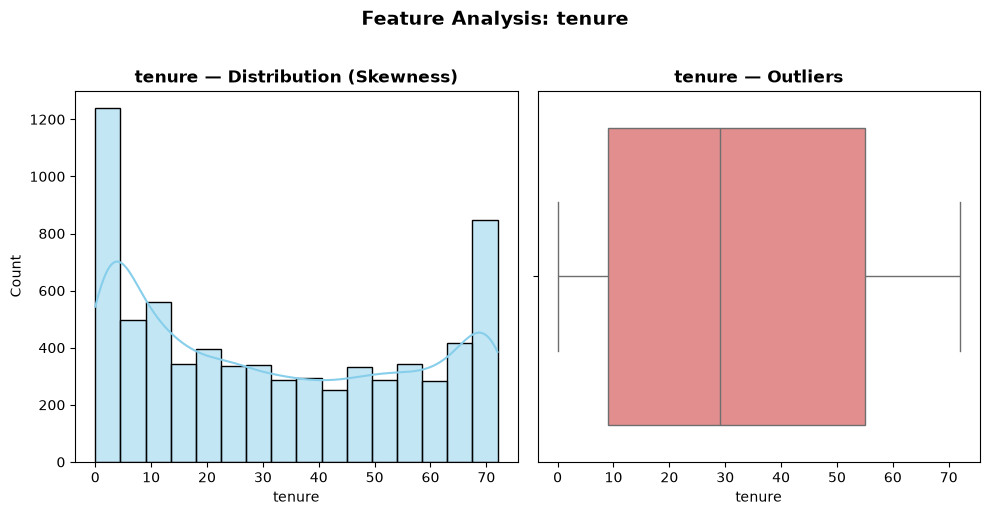

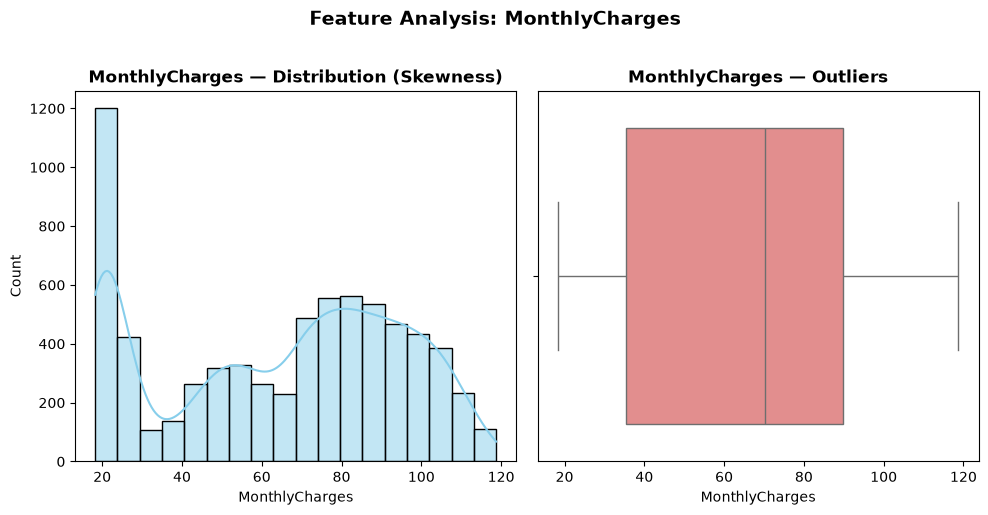

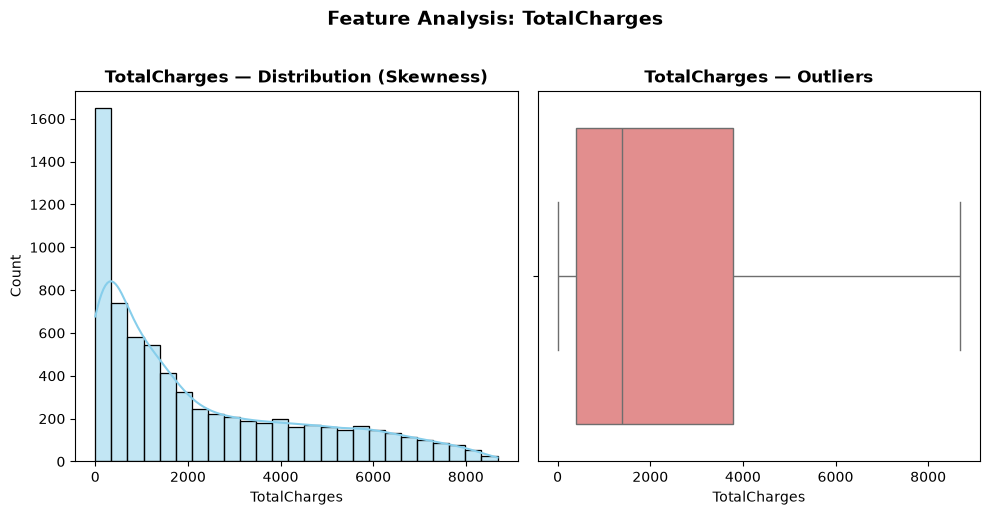

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['tenure', 'MonthlyCharges', 'TotalCharges']


for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Left subplot: Vertical Histogram with KDE (Skewness)
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} — Distribution (Skewness)', fontweight='bold')
    
    # Right subplot: Vertical Boxplot (Outliers)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} — Outliers', fontweight='bold')
    
    plt.suptitle(f'Feature Analysis: {col}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\2032901789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')


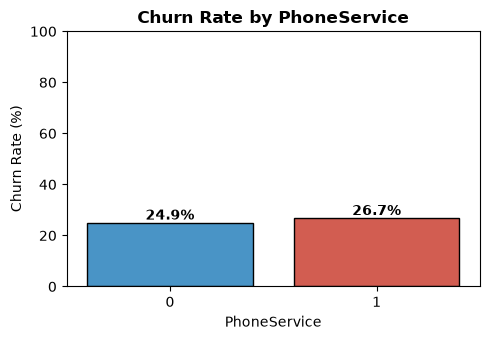

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\2032901789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')


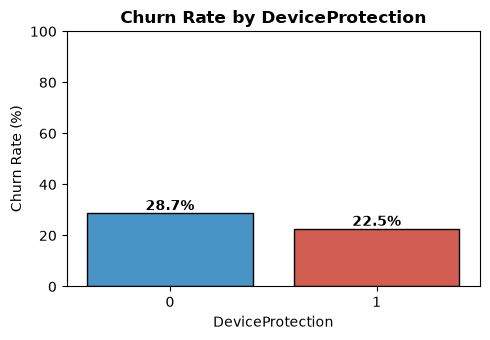

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\2032901789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')


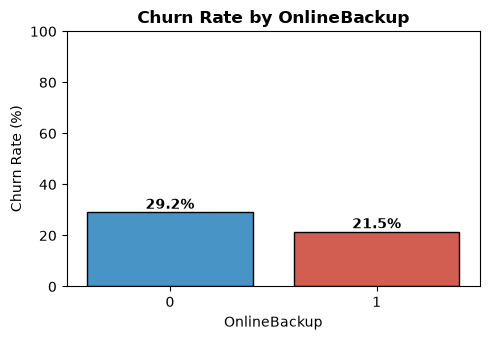

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\2032901789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')
C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\2032901789.py:10: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')


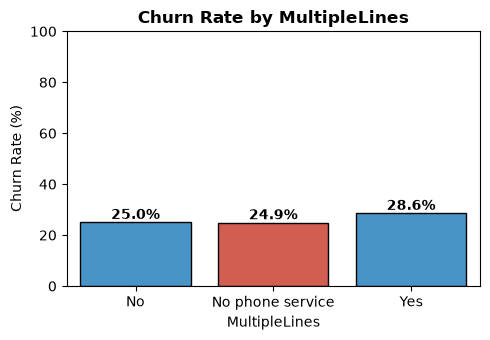

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\2032901789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')


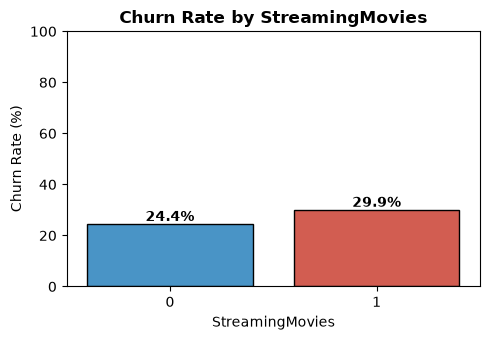

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\2032901789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')


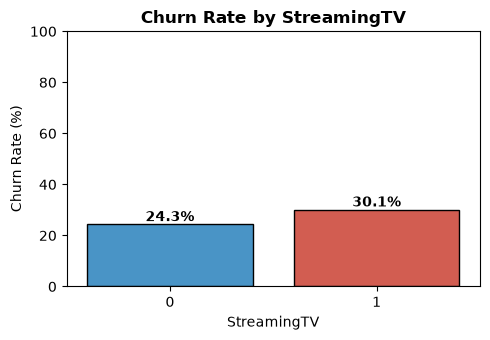

In [15]:
binary_cols = ['PhoneService','DeviceProtection','OnlineBackup','MultipleLines','StreamingMovies','StreamingTV']

for col in binary_cols:
    plt.figure(figsize=(5, 3.5))
    
    # Calculate churn rate percentage
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate['Churn_%'] = churn_rate['Churn'] * 100
    
    ax = sns.barplot(data=churn_rate, x=col, y='Churn_%', palette=['#3498db', '#e74c3c'], edgecolor='black')
    
    # Annotate bars with exact percentages
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
        
    plt.title(f'Churn Rate by {col}', fontweight='bold')
    plt.ylabel('Churn Rate (%)')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\1650975584.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\1650975584.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


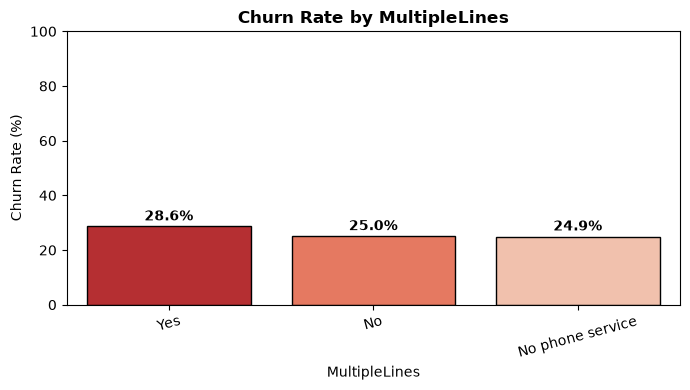

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\1650975584.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


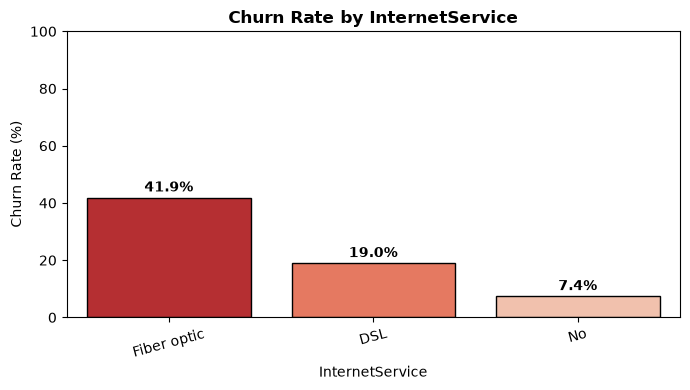

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\1650975584.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


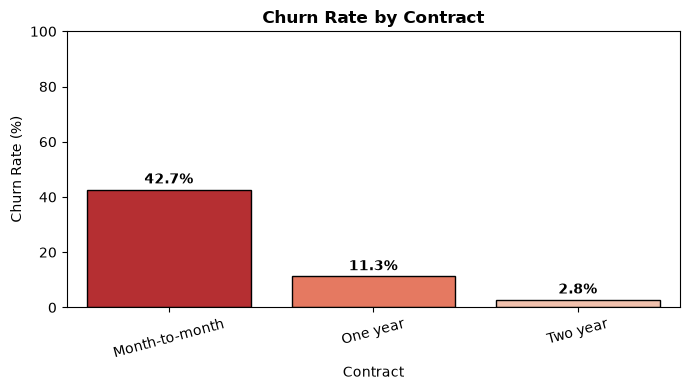

C:\Users\elmhl\AppData\Local\Temp\ipykernel_18700\1650975584.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


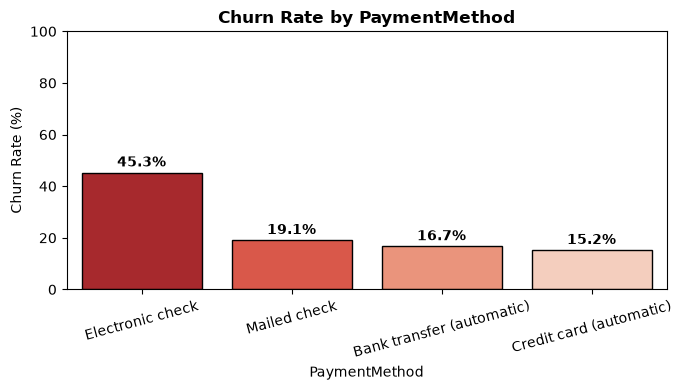

In [16]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'customerID' in cat_cols:
    cat_cols.remove('customerID')

# Generate a Churn Rate plot per categorical column
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    
    # Calculate churn rate percentage per category
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate['Churn_Percent'] = churn_rate['Churn'] * 100
    churn_rate = churn_rate.sort_values(by='Churn_Percent', ascending=False)
    
    # Bar plot
    ax = sns.barplot(
        data=churn_rate, 
        x=col, 
        y='Churn_Percent', 
        palette='Reds_r', 
        edgecolor='black'
    )
    
    # Add percentage labels on top of each bar
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%", 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 7), 
            textcoords='offset points', 
            fontweight='bold'
        )
        
    plt.title(f'Churn Rate by {col}', fontweight='bold')
    plt.ylabel('Churn Rate (%)')
    plt.xlabel(col)
    plt.ylim(0, 100)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [17]:
df = df.drop(columns=['TotalCharges'])

In [18]:
addon_cols = [
    'OnlineSecurity', 
    'OnlineBackup', 
    'DeviceProtection', 
    'TechSupport', 
    'StreamingTV', 
    'StreamingMovies'
]


df['TotalServicesCount'] = df[addon_cols].sum(axis=1)

df = df.drop(columns=addon_cols)
df = df.drop(columns='MultipleLines')

In [19]:
df.corr(numeric_only=True)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,TotalServicesCount
SeniorCitizen,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.150889,0.067493
Partner,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,-0.150448,0.204237
Dependents,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,-0.164221,0.030200
tenure,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,-0.352229,0.494263
PhoneService,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.011942,-0.092810
PaperlessBilling,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.191825,0.182481
MonthlyCharges,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.193356,0.724706
Churn,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,1.000000,-0.087698
TotalServicesCount,0.067493,0.204237,0.030200,0.494263,-0.092810,0.182481,0.724706,-0.087698,1.000000


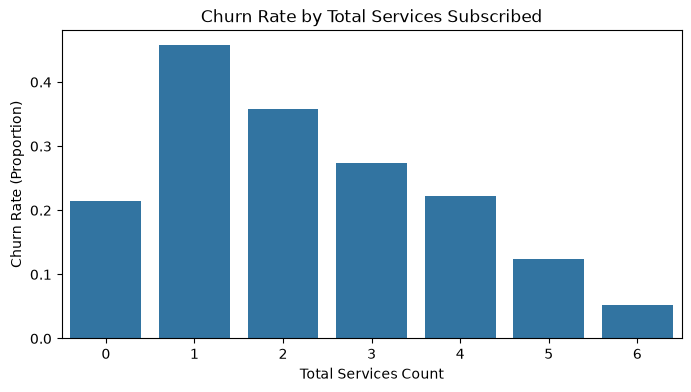

In [20]:
plt.figure(figsize=(8, 4))
sns.barplot(x='TotalServicesCount', y='Churn', data=df, errorbar=None)
plt.title('Churn Rate by Total Services Subscribed')
plt.ylabel('Churn Rate (Proportion)')
plt.xlabel('Total Services Count')
plt.show()


In [22]:
df.to_csv('../data/processed/cleaned_churn_data.csv', index=False)